In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

from pathlib import Path
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils import load_config
from src.validation import get_tpcf

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helpers and Functions

In [2]:
WIDTH_LATEX = 4.9
FONT_COLOR = "0" # or "#0E1D35" for the dark blue as per pp theme

In [3]:
def find_equally_spaced_indices(arr, n):
    "Based on specific conditioning parameter."
    sorted_indices = np.argsort(arr)
    sorted_arr = arr[sorted_indices]
    min_val, max_val = sorted_arr[0], sorted_arr[-1]
    division_points = np.linspace(min_val, max_val, n)
    closest_indices = np.searchsorted(sorted_arr, division_points)
    closest_indices = np.clip(closest_indices, 0, len(arr) - 1)
    original_indices = sorted_indices[closest_indices]
    return original_indices

In [4]:
#### Calculate 2pcf for sampled
def calc_tpcf_gen(gen_array, scale=True):
    """
    gen array must have size: # cosmology, # repeats, # particles, 3
    """
    gen_tpcf = []
    for i in tqdm(range(gen_array.shape[0])):     # Loop over cosmologies
        inter_gen_tpcf = []
        for j in range(gen_array[i].shape[0]):    # Loop over number of repeats for cosmology
            if scale:
                inter_gen_tpcf.append(get_tpcf(gen_array[i][j] * 1000, boxsize, r_bins, mu_bins))
            else:
                inter_gen_tpcf.append(get_tpcf(gen_array[i][j], boxsize, r_bins, mu_bins))
        gen_tpcf.append(np.array(inter_gen_tpcf))
    gen_tpcf = np.array(gen_tpcf)

    return gen_tpcf

In [5]:
#### Calculate MAE
def calc_mae(sim_tpcf, gen_tpcf):
    
    mae = np.mean(np.absolute(sim_tpcf[:, None] - gen_tpcf), axis=(0, 1))
    mae_total = np.mean(mae)
    print("mae:", mae)
    print("mae total:", mae_total)

    return mae, mae_total

In [6]:
#### Calculate MSE 
def calc_mse(sim_tpcf, gen_tpcf):
    mse = np.mean((sim_tpcf[:, None] - gen_tpcf)**2, axis=(0, 1))
    mse_total = np.mean(mse)
    print("mse:", mse)
    print("mse total:", mse_total)

    return mse, mse_total

### Data Loading and Preprocessing

In [7]:
# Two-Point Correlation function
boxsize = 1000.
r_bins = np.linspace(0.5, 150.0, 25) # Defines 25 linearly spaced bins from 0.5 to 150 for the radial separation r
r_c = 0.5*(r_bins[1:] + r_bins[:-1]) # Computes the center of each radial bin (midpoint between two consecutive bins)
mu_bins = np.linspace(-1, 1, 201)

In [8]:
# In and Out Directories
train_run = "20260402_172315"
infer_run = "20260406_145027"
config_dir = f"/gpfs/home4/bartb/T5000/T5000-OVF/results/run_{train_run}/qualitative_2pcf/{infer_run}/final_config.yaml"
config = load_config(config_dir)
output_dir = os.path.dirname(config_dir)

In [9]:
# Load true and generated samples
gen_samples = torch.load(f"/gpfs/home4/bartb/T5000/T5000-OVF/results/run_{train_run}/qualitative_2pcf/{infer_run}/gen_samples.pth", weights_only=False).squeeze(0)
# gen_samples = torch.load("/gpfs/home4/bartb/T5000/results/run_20260309_153121/qualitative_2pcf/20260310_105417/gen_samples.pth", weights_only=False).squeeze(0)
print(f"Shape of generated samples: {gen_samples.shape}")

# batches, batch_size, repeats, halos, D = gen_samples.shape[0], gen_samples.shape[1], gen_samples.shape[2], gen_samples.shape[3], gen_samples.shape[4]
# gen_samples = gen_samples.reshape(batches*batch_size, repeats, halos, D)
# print(f"Shape of generated samples after reshaping: {gen_samples.shape}")

true_samples = torch.from_numpy(np.load("/gpfs/home4/bartb/T5000/Data/test_halos.npy")[..., :3])
print(f"Shape of true samples: {true_samples.shape}")

Shape of generated samples: (5, 5, 5000, 3)
Shape of true samples: torch.Size([200, 5000, 3])


In [10]:
# Load parameters
params = pd.read_csv("/gpfs/home4/bartb/T5000/Data/test_cosmology.csv").values
print(f"Shape of parameters: {params.shape}")

Shape of parameters: (200, 5)


In [11]:
### equally spaced based on Omega_m! : conditioning[:, 0]
equally_spaced = 20
params_idx_used = find_equally_spaced_indices(params[:,0], equally_spaced)
params_used = params[params_idx_used]
true_samples_used = true_samples[params_idx_used][ :, :, :3] / 1000 # normalize coordinates
print(f"Shape of true samples used: {true_samples_used.shape}")

Shape of true samples used: torch.Size([20, 5000, 3])


In [12]:
### 2PCF on true cosmologies, only 5 of them!
print(true_samples_used.shape)
true_samples_used = true_samples_used[::4]
print(true_samples_used.shape)
params_used = params_used[::4]#[:, [0, -1]]
print(f"Shape of parameters used: {params_used.shape}")
print(f"First 5 conditioning vectors: {params_used[:5, :]}")

tcpf_true = []
for i in range(len(true_samples_used)):
    tcpf_true.append(get_tpcf(true_samples_used[i]*1000, boxsize, r_bins, mu_bins))
tcpf_true = np.array(tcpf_true)
print(tcpf_true.shape)

torch.Size([20, 5000, 3])
torch.Size([5, 5000, 3])
Shape of parameters used: (5, 5)
First 5 conditioning vectors: [[0.1001  0.05047 0.8959  1.0103  0.9203 ]
 [0.1839  0.04711 0.8675  1.0421  0.6845 ]
 [0.2683  0.03749 0.7533  0.9845  0.9205 ]
 [0.3539  0.06139 0.6681  0.8327  0.6243 ]
 [0.4365  0.06281 0.7347  1.0699  0.9509 ]]


/home/bartb/venvs/boids/lib/python3.11/site-packages/pycorr/corrfunc.py:153: UserWarning: These arguments are not read: {'n_threads': 2}
  warnings.warn('These arguments are not read: {}'.format(attrs))


(5, 24)


In [13]:
n_cosmologies = true_samples_used.shape[0]
n_repeats = config["inference"]["n_repeats"]
print(f"Number of cosmologies: {n_cosmologies}, Number of repeats: {n_repeats}") 

Number of cosmologies: 5, Number of repeats: 5


In [14]:
### 2PCF on generated cosmologies
tcpf_gen = calc_tpcf_gen(gen_samples, scale=True)  

100%|██████████| 5/5 [00:00<00:00, 32.37it/s]


In [15]:
print(tcpf_gen.shape)

(5, 5, 24)


In [16]:
mae, mae_total = calc_mae(tcpf_true, tcpf_gen)
mse, mse_total = calc_mse(tcpf_true, tcpf_gen)

mae: [7.92893509e+02 3.32391362e+01 4.99244367e+00 2.48220070e+00
 1.62728784e+00 1.37471541e+00 1.05515149e+00 7.17963362e-01
 7.71307504e-01 9.65070965e-01 7.93330666e-01 9.14140554e-01
 8.17410627e-01 8.22978068e-01 8.77212636e-01 8.52227215e-01
 8.01150576e-01 7.40390602e-01 7.51442583e-01 7.46848613e-01
 8.07773227e-01 7.17139536e-01 7.39156906e-01 6.78391915e-01]
mae total: 35.46576581230726
mse: [7.26175828e+05 1.58646955e+03 4.47705271e+01 1.06716950e+01
 3.93845821e+00 2.37192960e+00 1.44651962e+00 7.31281052e-01
 8.25148478e-01 1.08907295e+00 8.19924864e-01 9.11507819e-01
 7.77421394e-01 7.29889297e-01 8.11487398e-01 7.82955186e-01
 7.25409425e-01 6.17811657e-01 6.35968131e-01 6.09539852e-01
 6.81513362e-01 5.59664327e-01 5.89922653e-01 4.98990912e-01]
mse total: 30326.578910770844


### Plots

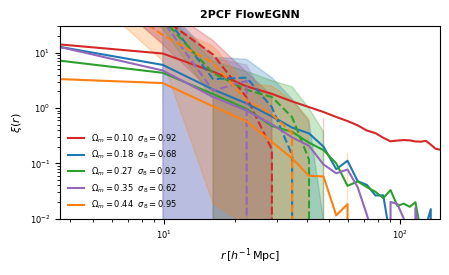

In [17]:
prop_cycle = plt.rcParams['axes.prop_cycle']

# Extract the colors from the prop_cycle
colors = prop_cycle.by_key()['color']

colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.5))
for i, idx in enumerate(range(0, n_cosmologies)):
    gen_mean = np.mean(tcpf_gen[idx, :], axis=0)
    gen_std  = np.std(tcpf_gen[idx, :],  axis=0)

    ax.fill_between(
        r_c, 
        gen_mean - gen_std, 
        gen_mean + gen_std, 
        alpha=0.25,
        color=colors[i],
    )
    ax.plot(r_c, gen_mean, linestyle='--', color=colors[i])
    ax.plot(r_c, tcpf_true[idx], label= rf'$\Omega_m = {params_used[idx][0]:.2f} \, \, \, \,  \sigma_8 = {params_used[idx][-1]:.2f}$', color=colors[i],)
ax.set_title("2PCF FlowEGNN", fontsize=8, fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1.e-2, 30)
ax.set_xlim(r_c[0],r_c[-1])
ax.set_ylabel(r'$\xi(r)$', color=FONT_COLOR, fontsize=8)
ax.set_xlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", color=FONT_COLOR, fontsize=8)
ax.tick_params(colors=FONT_COLOR, which='both', labelsize=6)

handles, labels = ax.get_legend_handles_labels() 

order = [0, 1, 2, 3, 4]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

ax.legend(handles=handles,
    # bbox_to_anchor=(1.15,1.30),
    labelcolor=FONT_COLOR,
    fontsize=6,
    loc='lower left',
    # ncol=3, 
         framealpha=0)
# fig.savefig(f"/home/donutu/galaxy-score/final_plots/quali_tpcf_score.pdf", dpi=1200, transparent=True, bbox_inches='tight');
# fig.savefig(f"/home/donutu/galaxy-score/final_plots/quali_tpcf_score.png", dpi=1200, transparent=True, bbox_inches='tight');

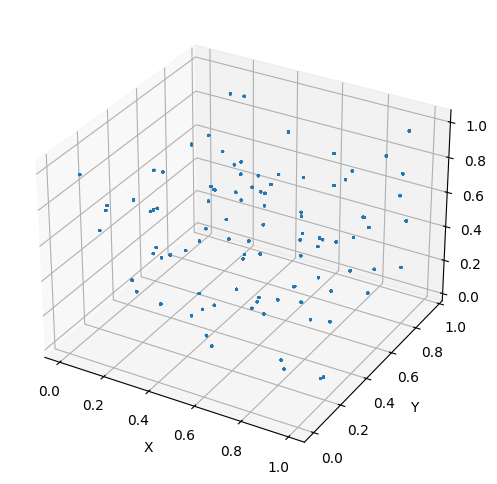

In [18]:
# Visualization of a generated sample
halos = gen_samples[0][0]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()


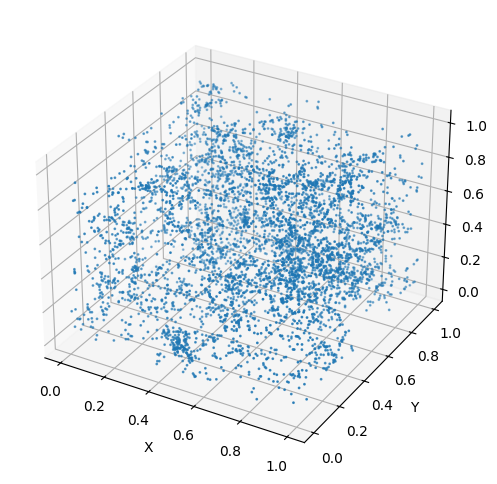

In [19]:
# Visualization of a generated sample
halos = true_samples_used[0]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()